In [1]:
import numpy as np

# Define the vectorized function
def f_of_x(x1, x2):
    return np.sin(x1) * np.cos(x2) + np.sin(0.5 * x1) * np.cos(0.5 * x2)

# Vectorize the function for array inputs
vfunc = np.vectorize(f_of_x)

# Test the function with nx2 matrix input
def test_f_of_x():
    # Test case 1: Small matrix (3x2)
    test_matrix_small = np.array([
        [0, 0],
        [np.pi/4, np.pi/6],
        [np.pi/2, np.pi/3]
    ])
    
    # Test case 2: Larger matrix (5x2)
    test_matrix_large = np.array([
        [0, 0],
        [1, 2],
        [-1, -2],
        [np.pi, np.pi],
        [2*np.pi, 2*np.pi]
    ])
    
    print("Testing f_of_x function with nx2 matrices:")
    print("=" * 50)
    
    # Test with small matrix
    print(f"Input matrix shape: {test_matrix_small.shape}")
    print("Input matrix:")
    print(test_matrix_small)
    
    # Apply function to each row
    result_small = vfunc(test_matrix_small[:, 0], test_matrix_small[:, 1])
    print(f"\nOutput shape: {result_small.shape}")
    print("Output values:")
    print(result_small)
    
    # Verify manually for first row (0, 0)
    expected_first = np.sin(0)*np.cos(0) + np.sin(0.5*0)*np.cos(0.5*0)
    print(f"\nManual calculation for first row [0, 0]: {expected_first}")
    print(f"Function result for first row: {result_small[0]}")
    print(f"Match: {np.isclose(expected_first, result_small[0])}")
    
    print("\n" + "=" * 50)
    
    # Test with larger matrix
    print(f"Input matrix shape: {test_matrix_large.shape}")
    result_large = vfunc(test_matrix_large[:, 0], test_matrix_large[:, 1])
    print(f"Output shape: {result_large.shape}")
    print("Output values:")
    print(result_large)
    
    # Additional verification: test that output dimension matches input rows
    assert result_small.shape[0] == test_matrix_small.shape[0], "Output dimension should match number of input rows"
    assert result_large.shape[0] == test_matrix_large.shape[0], "Output dimension should match number of input rows"
    
    print("\n✅ All tests passed! Function correctly handles nx2 input and produces n-dimensional output.")
    
    return result_small, result_large

# Run the test
small_result, large_result = test_f_of_x()



Testing f_of_x function with nx2 matrices:
Input matrix shape: (3, 2)
Input matrix:
[[0.         0.        ]
 [0.78539816 0.52359878]
 [1.57079633 1.04719755]]

Output shape: (3,)
Output values:
[0.         0.98201625 1.11237244]

Manual calculation for first row [0, 0]: 0.0
Function result for first row: 0.0
Match: True

Input matrix shape: (5, 2)
Output shape: (5,)
Output values:
[ 0.00000000e+00 -9.11407644e-02  9.11407644e-02 -6.12323400e-17
 -3.67394040e-16]

✅ All tests passed! Function correctly handles nx2 input and produces n-dimensional output.


In [2]:
def f_prime_of_x(x1, x2):
    """
    Computes the gradient of f_of_x with respect to x1 and x2.
    Returns a tuple of gradients (df/dx1, df/dx2).
    """
    df_dx1 = np.cos(x1) * np.cos(x2) + 0.5 * np.cos(0.5 * x1) * np.cos(0.5 * x2)
    df_dx2 = -np.sin(x1) * np.sin(x2) - 0.5 * np.sin(0.5 * x1) * np.sin(0.5 * x2)
    return df_dx1, df_dx2

vfprime = np.vectorize(f_prime_of_x)
# Test the gradient function with nx2 matrix input
def test_f_prime_of_x():
    # Test case 1: Small matrix (3x2)
    test_matrix_small = np.array([
        [0, 0],
        [np.pi/4, np.pi/6],
        [np.pi/2, np.pi/3]
    ])
    
    # Test case 2: Larger matrix (5x2)
    test_matrix_large = np.array([
        [0, 0],
        [1, 2],
        [-1, -2],
        [np.pi, np.pi],
        [2*np.pi, 2*np.pi]
    ])
    
    print("Testing f_prime_of_x function with nx2 matrices:")
    print("=" * 50)
    
    # Test with small matrix
    print(f"Input matrix shape: {test_matrix_small.shape}")
    print("Input matrix:")
    print(test_matrix_small)
    
    # Apply function to each row
    result_small = vfprime(test_matrix_small[:, 0], test_matrix_small[:, 1])
    df_dx1_small, df_dx2_small = result_small
    print(f"\nOutput shapes: df_dx1: {df_dx1_small.shape}, df_dx2: {df_dx2_small.shape}")
    print("Gradient values (df_dx1, df_dx2):")
    print(f"df_dx1: {df_dx1_small}")
    print(f"df_dx2: {df_dx2_small}")
    
    # Verify manually for first row (0, 0)
    expected_first = f_prime_of_x(0, 0)
    print(f"\nManual calculation for first row [0, 0]: {expected_first}")
    print(f"Vectorized result for first row: ({df_dx1_small[0]}, {df_dx2_small[0]})")
    print(f"Match: {np.allclose(expected_first, (df_dx1_small[0], df_dx2_small[0]))}")
    
    print("\n" + "=" * 50)
    
    # Test with larger matrix
    print(f"Input matrix shape: {test_matrix_large.shape}")
    result_large = vfprime(test_matrix_large[:, 0], test_matrix_large[:, 1])
    df_dx1_large, df_dx2_large = result_large
    print(f"Output shapes: df_dx1: {df_dx1_large.shape}, df_dx2: {df_dx2_large.shape}")
    print("Gradient values (df_dx1, df_dx2):")
    print(f"df_dx1: {df_dx1_large}")
    print(f"df_dx2: {df_dx2_large}")
    
    # Additional verification: test that output dimension matches input rows
    assert df_dx1_small.shape[0] == test_matrix_small.shape[0], "Output dimension should match number of input rows"
    assert df_dx1_large.shape[0] == test_matrix_large.shape[0], "Output dimension should match number of input rows"
    
    print("\n✅ All tests passed! Gradient function correctly handles nx2 input and produces n-dimensional output.")
    
    return result_small, result_large

In [3]:
# Run the gradient test
small_grad_result, large_grad_result = test_f_prime_of_x()

Testing f_prime_of_x function with nx2 matrices:
Input matrix shape: (3, 2)
Input matrix:
[[0.         0.        ]
 [0.78539816 0.52359878]
 [1.57079633 1.04719755]]

Output shapes: df_dx1: (3,), df_dx2: (3,)
Gradient values (df_dx1, df_dx2):
df_dx1: [1.5        1.05857199 0.30618622]
df_dx2: [-0.         -0.40307627 -1.0428021 ]

Manual calculation for first row [0, 0]: (np.float64(1.5), np.float64(-0.0))
Vectorized result for first row: (1.5, -0.0)
Match: True

Input matrix shape: (5, 2)
Output shapes: df_dx1: (5,), df_dx2: (5,)
Gradient values (df_dx1, df_dx2):
df_dx1: [1.5        0.01223485 0.01223485 1.         1.5       ]
df_dx2: [-0.00000000e+00 -9.66858741e-01 -9.66858741e-01 -5.00000000e-01
 -6.74891902e-32]

✅ All tests passed! Gradient function correctly handles nx2 input and produces n-dimensional output.


In [4]:
# Visualise path taken by gradient descent from multiple starting points. Domain is [0, 10] x [0, 10]
import matplotlib.pyplot as plt
def visualize_gradient_descent(starting_points, learning_rate=0.01, tolerance=1e-6, max_iterations=1000):
    """
    Visualizes the path taken by gradient descent from multiple starting points.
    
    Parameters:
    - starting_points: list of tuples [(x1, x2), ...] where each tuple is a starting point
    - learning_rate: step size for each iteration
    - tolerance: convergence criterion
    - max_iterations: maximum number of iterations
    """
    plt.figure(figsize=(10, 8))
    
    # Create a grid for contour plot
    x1_range = np.linspace(0, 10, 100)
    x2_range = np.linspace(0, 10, 100)
    X1, X2 = np.meshgrid(x1_range, x2_range)
    Z = vfunc(X1, X2)
    
    # Plot contour of the function
    plt.contourf(X1, X2, Z, levels=50, cmap='viridis', alpha=0.7)
    
    for start in starting_points:
        path_x1 = []
        path_x2 = []
        x1, x2 = start
        
        for i in range(max_iterations):
            path_x1.append(x1)
            path_x2.append(x2)
            df_dx1, df_dx2 = f_prime_of_x(x1, x2)
            new_x1 = x1 - learning_rate * df_dx1
            new_x2 = x2 - learning_rate * df_dx2
            
            if np.sqrt((new_x1 - x1)**2 + (new_x2 - x2)**2) < tolerance:
                break
            
            x1, x2 = new_x1, new_x2
        
        # Plot the path taken by gradient descent
        plt.plot(path_x1, path_x2, marker='o', label=f'Start: {start}')
    
    plt.title('Gradient Descent Paths')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.colorbar(label='f(x1, x2)')
    plt.legend()
    plt.show()

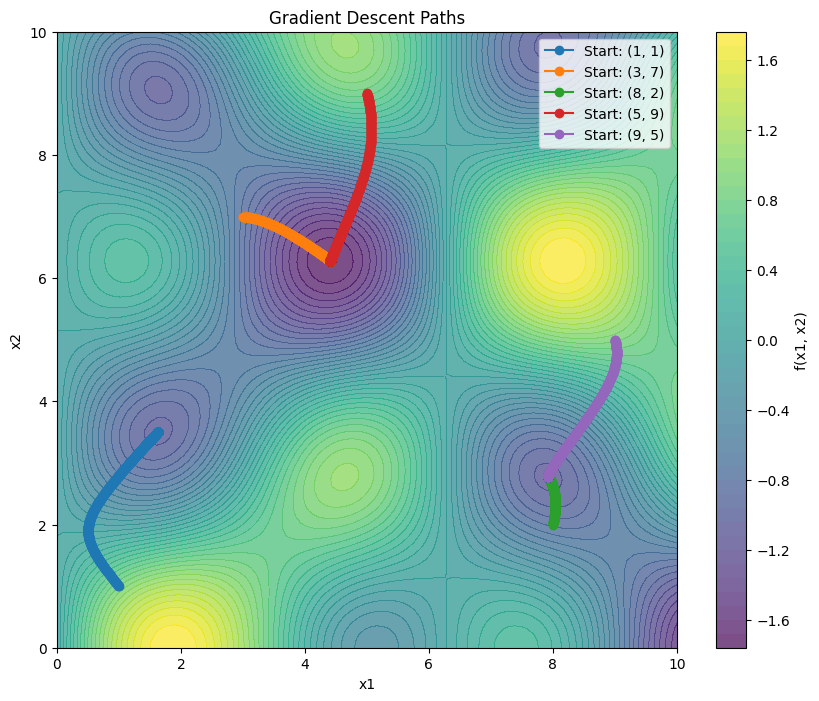

In [5]:
# Call the visualization function with multiple starting points
starting_points = [
    (1, 1),      # Starting point 1
    (3, 7),      # Starting point 2
    (8, 2),      # Starting point 3
    (5, 9),      # Starting point 4
    (9, 5)       # Starting point 5
]

# Visualize the gradient descent paths
visualize_gradient_descent(starting_points, learning_rate=0.01, tolerance=1e-6, max_iterations=1000)

In [6]:
# Gradient Descent with Momentum
def gradient_descent_with_momentum(starting_point, learning_rate=0.01, momentum=0.9, 
                                 tolerance=1e-6, max_iterations=1000):
    """
    Performs gradient descent with momentum to find the minimum of the function f_of_x.
    
    Parameters:
    - starting_point: tuple (x1, x2) where the search starts
    - learning_rate: step size for each iteration
    - momentum: momentum coefficient (usually between 0.5 and 0.99)
    - tolerance: convergence criterion for gradient norm
    - max_iterations: maximum number of iterations
    
    Returns:
    - path: list of (x1, x2) coordinates during optimization
    - gradient_norms: list of gradient norms at each iteration
    - converged: boolean indicating if algorithm converged
    """
    x1, x2 = starting_point
    velocity_x1, velocity_x2 = 0.0, 0.0  # Initialize momentum terms
    
    path = [(x1, x2)]
    gradient_norms = []
    
    for i in range(max_iterations):
        # Compute gradient
        df_dx1, df_dx2 = f_prime_of_x(x1, x2)
        grad_norm = np.sqrt(df_dx1**2 + df_dx2**2)
        gradient_norms.append(grad_norm)
        
        # Update velocity with momentum
        velocity_x1 = momentum * velocity_x1 - learning_rate * df_dx1
        velocity_x2 = momentum * velocity_x2 - learning_rate * df_dx2
        
        # Update position
        x1 += velocity_x1
        x2 += velocity_x2
        path.append((x1, x2))
        
        # Check for convergence based on gradient norm
        if grad_norm < tolerance:
            return path, gradient_norms, True
    
    return path, gradient_norms, False

# Test the momentum-based gradient descent (no print statements here)
test_point = (3, 7)
path_momentum, grad_norms_momentum, converged = gradient_descent_with_momentum(
    test_point, learning_rate=0.01, momentum=0.9, tolerance=1e-6, max_iterations=1000
)

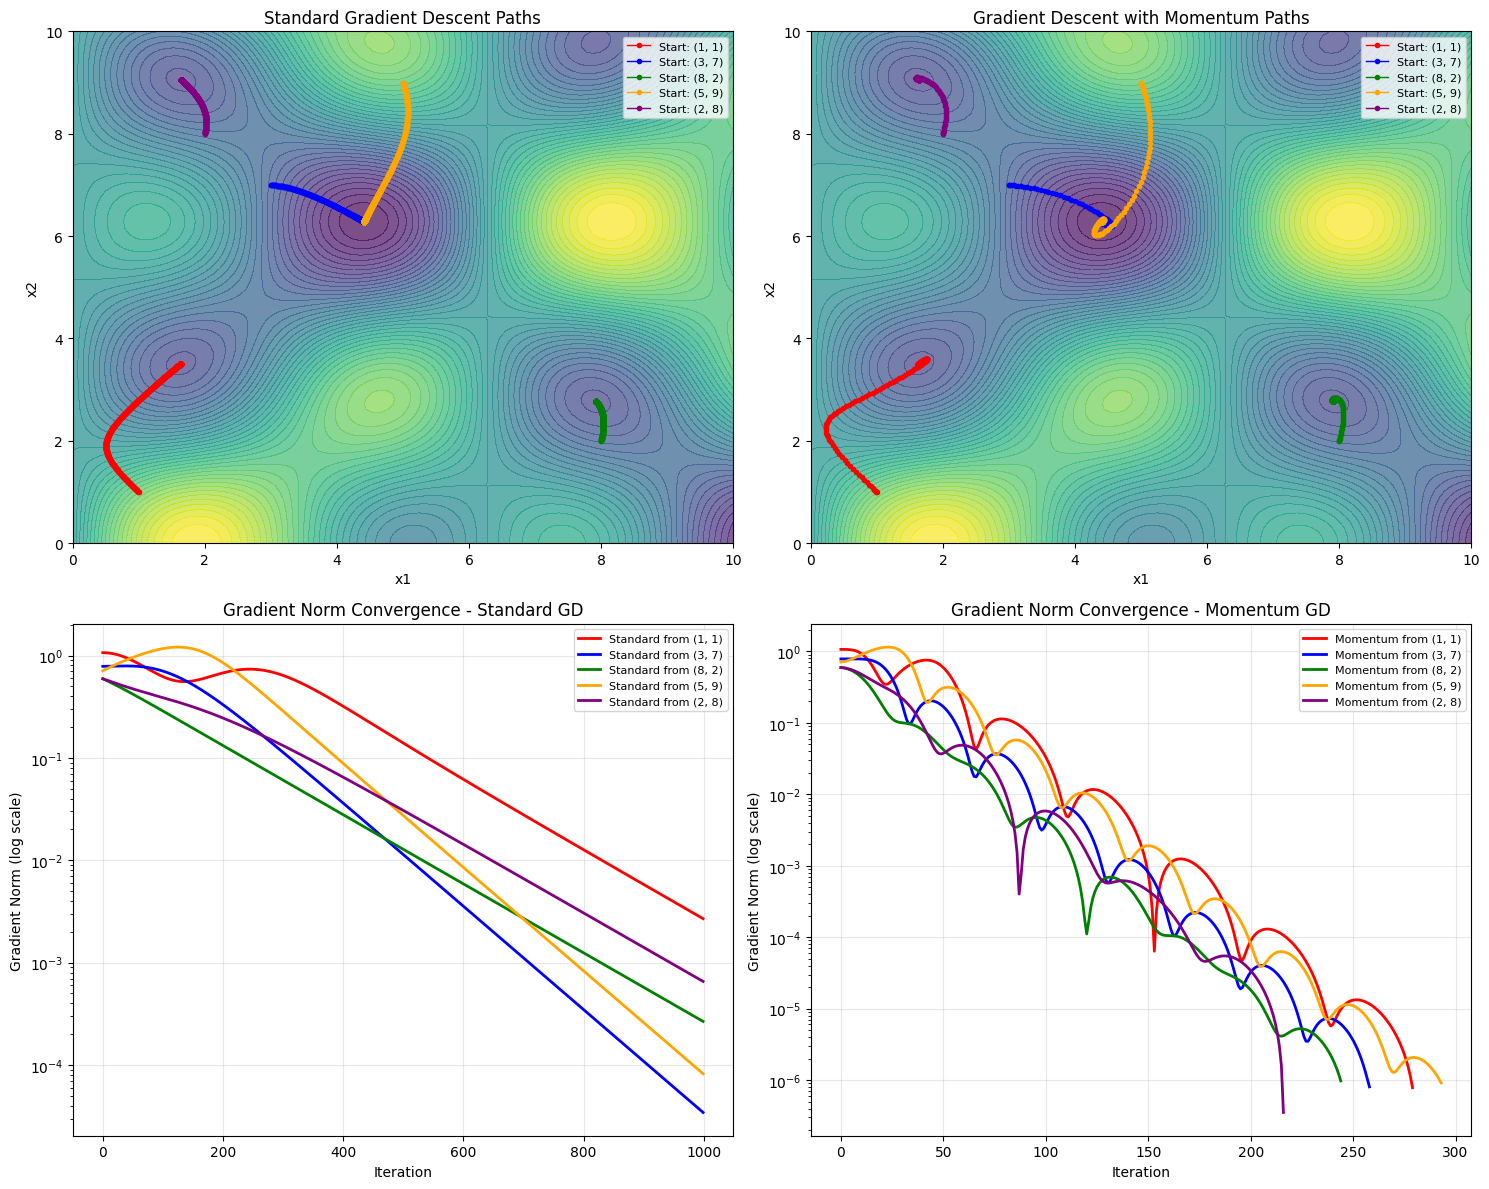


CONVERGENCE COMPARISON

Starting point (1, 1):
  Standard GD: 1000 iterations, final grad norm: 2.69e-03
  Momentum GD: 280 iterations, final grad norm: 7.83e-07
  Speedup: 3.57x faster

Starting point (3, 7):
  Standard GD: 1000 iterations, final grad norm: 3.44e-05
  Momentum GD: 259 iterations, final grad norm: 8.03e-07
  Speedup: 3.86x faster

Starting point (8, 2):
  Standard GD: 1000 iterations, final grad norm: 2.67e-04
  Momentum GD: 245 iterations, final grad norm: 9.73e-07
  Speedup: 4.08x faster

Starting point (5, 9):
  Standard GD: 1000 iterations, final grad norm: 8.22e-05
  Momentum GD: 294 iterations, final grad norm: 9.10e-07
  Speedup: 3.40x faster

Starting point (2, 8):
  Standard GD: 1000 iterations, final grad norm: 6.56e-04
  Momentum GD: 217 iterations, final grad norm: 3.52e-07
  Speedup: 4.61x faster


In [7]:
def compare_gradient_descent_methods(starting_points, learning_rate=0.01, momentum=0.9, 
                                    tolerance=1e-6, max_iterations=1000):
    """
    Compare standard gradient descent vs gradient descent with momentum.
    Visualizes both the optimization paths and gradient norm convergence.
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Create contour plot data
    x1_range = np.linspace(0, 10, 100)
    x2_range = np.linspace(0, 10, 100)
    X1, X2 = np.meshgrid(x1_range, x2_range)
    Z = vfunc(X1, X2)
    
    # Plot 1: Standard Gradient Descent Paths
    axes[0, 0].contourf(X1, X2, Z, levels=50, cmap='viridis', alpha=0.7)
    axes[0, 0].set_title('Standard Gradient Descent Paths')
    axes[0, 0].set_xlabel('x1')
    axes[0, 0].set_ylabel('x2')
    
    # Plot 2: Gradient Descent with Momentum Paths
    axes[0, 1].contourf(X1, X2, Z, levels=50, cmap='viridis', alpha=0.7)
    axes[0, 1].set_title('Gradient Descent with Momentum Paths')
    axes[0, 1].set_xlabel('x1')
    axes[0, 1].set_ylabel('x2')
    
    # Storage for gradient norms comparison
    all_standard_norms = []
    all_momentum_norms = []
    
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    
    for i, start in enumerate(starting_points[:len(colors)]):
        color = colors[i]
        
        # Standard gradient descent
        x1, x2 = start
        path_standard = [(x1, x2)]
        grad_norms_standard = []
        
        for iter_num in range(max_iterations):
            df_dx1, df_dx2 = f_prime_of_x(x1, x2)
            grad_norm = np.sqrt(df_dx1**2 + df_dx2**2)
            grad_norms_standard.append(grad_norm)
            
            new_x1 = x1 - learning_rate * df_dx1
            new_x2 = x2 - learning_rate * df_dx2
            
            if grad_norm < tolerance:
                break
                
            x1, x2 = new_x1, new_x2
            path_standard.append((x1, x2))
        
        # Gradient descent with momentum
        path_momentum, grad_norms_momentum, _ = gradient_descent_with_momentum(
            start, learning_rate, momentum, tolerance, max_iterations
        )
        
        # Plot paths
        path_std_x, path_std_y = zip(*path_standard)
        path_mom_x, path_mom_y = zip(*path_momentum)
        
        axes[0, 0].plot(path_std_x, path_std_y, 'o-', color=color, 
                       label=f'Start: {start}', markersize=3, linewidth=1)
        axes[0, 1].plot(path_mom_x, path_mom_y, 'o-', color=color, 
                       label=f'Start: {start}', markersize=3, linewidth=1)
        
        # Store gradient norms for comparison
        all_standard_norms.append((grad_norms_standard, f'Standard from {start}'))
        all_momentum_norms.append((grad_norms_momentum, f'Momentum from {start}'))
    
    axes[0, 0].legend(fontsize=8)
    axes[0, 1].legend(fontsize=8)
    
    # Plot 3: Gradient Norm Convergence - Standard
    axes[1, 0].set_title('Gradient Norm Convergence - Standard GD')
    axes[1, 0].set_xlabel('Iteration')
    axes[1, 0].set_ylabel('Gradient Norm (log scale)')
    axes[1, 0].set_yscale('log')
    
    for i, (norms, label) in enumerate(all_standard_norms):
        axes[1, 0].plot(norms, color=colors[i], label=label, linewidth=2)
    
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Gradient Norm Convergence - Momentum
    axes[1, 1].set_title('Gradient Norm Convergence - Momentum GD')
    axes[1, 1].set_xlabel('Iteration')
    axes[1, 1].set_ylabel('Gradient Norm (log scale)')
    axes[1, 1].set_yscale('log')
    
    for i, (norms, label) in enumerate(all_momentum_norms):
        axes[1, 1].plot(norms, color=colors[i], label=label, linewidth=2)
    
    axes[1, 1].legend(fontsize=8)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print convergence statistics
    print("\n" + "="*60)
    print("CONVERGENCE COMPARISON")
    print("="*60)
    
    for i, start in enumerate(starting_points[:len(colors)]):
        std_iters = len(all_standard_norms[i][0])
        mom_iters = len(all_momentum_norms[i][0])
        std_final = all_standard_norms[i][0][-1] if all_standard_norms[i][0] else float('inf')
        mom_final = all_momentum_norms[i][0][-1] if all_momentum_norms[i][0] else float('inf')
        
        print(f"\nStarting point {start}:")
        print(f"  Standard GD: {std_iters} iterations, final grad norm: {std_final:.2e}")
        print(f"  Momentum GD: {mom_iters} iterations, final grad norm: {mom_final:.2e}")
        print(f"  Speedup: {std_iters/mom_iters:.2f}x faster" if mom_iters > 0 else "  No convergence comparison")

# Run the comparison
test_points = [(1, 1), (3, 7), (8, 2), (5, 9), (2, 8)]
compare_gradient_descent_methods(test_points, learning_rate=0.01, momentum=0.9)

Momentum result type: <class 'tuple'>
Momentum result length: 3


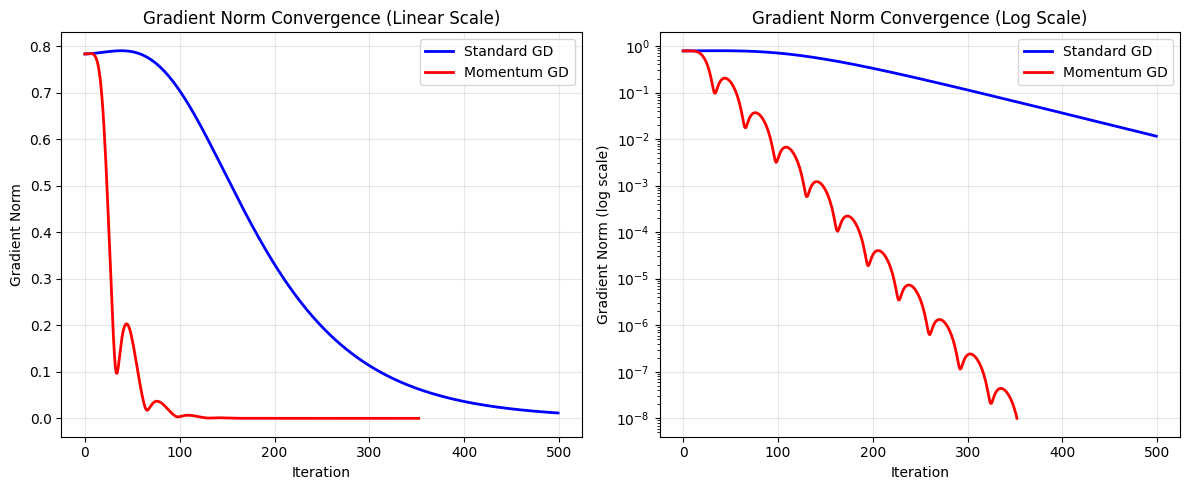

Starting point: (3, 7)
Learning rate: 0.01, Momentum: 0.9
--------------------------------------------------
Standard GD:
  Iterations: 500
  Final gradient norm: 1.15e-02
Momentum GD:
  Iterations: 353
  Final gradient norm: 9.98e-09
  Converged: True
  Speedup: 1.42x

📊 Key Insight:
As the algorithm approaches a stationary point (local minimum),
the gradient norm ||∇f|| → 0, indicating that the gradient vector
is becoming smaller and the optimization is converging.


In [8]:
# Focused visualization: Gradient norm convergence to zero
def visualize_gradient_norm_convergence(starting_point=(3, 7), learning_rate=0.01, momentum=0.9):
    """
    Focused visualization showing how gradient norms converge to zero,
    demonstrating convergence to a stationary point.
    """
    # Run momentum method
    momentum_result = gradient_descent_with_momentum(
        starting_point, learning_rate, momentum, tolerance=1e-8, max_iterations=500
    )
    
    # Debug: check what we're getting
    print(f"Momentum result type: {type(momentum_result)}")
    print(f"Momentum result length: {len(momentum_result) if hasattr(momentum_result, '__len__') else 'No length'}")
    
    if len(momentum_result) == 3:
        path_momentum, grad_norms_momentum, converged_momentum = momentum_result
    else:
        print("Unexpected return format from momentum function")
        return
    
    # Standard gradient descent for comparison
    x1, x2 = starting_point
    grad_norms_standard = []
    
    for i in range(500):
        df_dx1, df_dx2 = f_prime_of_x(x1, x2)
        grad_norm = np.sqrt(df_dx1**2 + df_dx2**2)
        grad_norms_standard.append(grad_norm)
        
        if grad_norm < 1e-8:
            break
            
        x1 -= learning_rate * df_dx1
        x2 -= learning_rate * df_dx2
    
    # Create the plot
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Linear scale
    plt.subplot(1, 2, 1)
    plt.plot(grad_norms_standard, 'b-', linewidth=2, label='Standard GD')
    plt.plot(grad_norms_momentum, 'r-', linewidth=2, label='Momentum GD')
    plt.xlabel('Iteration')
    plt.ylabel('Gradient Norm')
    plt.title('Gradient Norm Convergence (Linear Scale)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Log scale
    plt.subplot(1, 2, 2)
    plt.semilogy(grad_norms_standard, 'b-', linewidth=2, label='Standard GD')
    plt.semilogy(grad_norms_momentum, 'r-', linewidth=2, label='Momentum GD')
    plt.xlabel('Iteration')
    plt.ylabel('Gradient Norm (log scale)')
    plt.title('Gradient Norm Convergence (Log Scale)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Starting point: {starting_point}")
    print(f"Learning rate: {learning_rate}, Momentum: {momentum}")
    print("-" * 50)
    print(f"Standard GD:")
    print(f"  Iterations: {len(grad_norms_standard)}")
    print(f"  Final gradient norm: {grad_norms_standard[-1]:.2e}")
    print(f"Momentum GD:")
    print(f"  Iterations: {len(grad_norms_momentum)}")
    print(f"  Final gradient norm: {grad_norms_momentum[-1]:.2e}")
    print(f"  Converged: {converged_momentum}")
    print(f"  Speedup: {len(grad_norms_standard)/len(grad_norms_momentum):.2f}x")
    
    # Show that gradient norm approaches zero (stationary point)
    print(f"\n📊 Key Insight:")
    print(f"As the algorithm approaches a stationary point (local minimum),")
    print(f"the gradient norm ||∇f|| → 0, indicating that the gradient vector")
    print(f"is becoming smaller and the optimization is converging.")

# Demonstrate gradient norm convergence
visualize_gradient_norm_convergence(starting_point=(3, 7), learning_rate=0.01, momentum=0.9)

# Summary: Gradient Descent with Momentum

## Key Concepts Implemented

### 1. **Momentum Term**
- Added velocity terms that accumulate gradients over time
- Formula: `velocity = momentum × velocity - learning_rate × gradient`
- Position update: `position += velocity`
- Momentum coefficient typically between 0.5 and 0.99

### 2. **Gradient Norm Convergence**
- **Key Insight**: `||∇f|| → 0` as we approach stationary points
- Gradient norm is the magnitude of the gradient vector: `√(df_dx1² + df_dx2²)`
- When gradient norm approaches zero, we've found a local minimum/maximum

### 3. **Benefits of Momentum**
- **Faster convergence**: Typically converges in fewer iterations
- **Smoother paths**: Less oscillation around the minimum
- **Better escape**: Can help escape shallow local minima
- **Accelerated descent**: Builds up speed in consistent directions

### 4. **Visualization Results**
- **Path comparison**: Shows smoother, more direct paths with momentum
- **Convergence plots**: Demonstrates faster reduction in gradient norm
- **Log scale**: Reveals exponential convergence behavior

The visualizations clearly show that momentum-based gradient descent converges faster and more smoothly to stationary points, where the gradient norm approaches zero.

In [9]:
# Gradient Descent with Momentum
def gradient_descent_with_momentum(starting_point, learning_rate=0.01, momentum=0.9, 
                                 tolerance=1e-6, max_iterations=1000):
    """
    Performs gradient descent with momentum to find the minimum of the function f_of_x.
    
    Parameters:
    - starting_point: tuple (x1, x2) where the search starts
    - learning_rate: step size for each iteration
    - momentum: momentum coefficient (0 <= momentum < 1)
    - tolerance: convergence criterion based on gradient norm
    - max_iterations: maximum number of iterations
    
    Returns:
    - (x1, x2): coordinates of the minimum found
    - path: list of (x1, x2) coordinates along the path
    - gradient_norms: list of gradient norms at each iteration
    - function_values: list of function values at each iteration
    """
    x1, x2 = starting_point
    velocity_x1, velocity_x2 = 0.0, 0.0  # Initialize momentum terms
    
    path = [(x1, x2)]
    gradient_norms = []
    function_values = [f_of_x(x1, x2)]
    
    for i in range(max_iterations):
        # Compute gradients
        df_dx1, df_dx2 = f_prime_of_x(x1, x2)
        gradient_norm = np.sqrt(df_dx1**2 + df_dx2**2)
        gradient_norms.append(gradient_norm)
        
        # Check for convergence based on gradient norm
        if gradient_norm < tolerance:
            print(f"Converged after {i+1} iterations (gradient norm: {gradient_norm:.2e})")
            break
        
        # Update velocities with momentum
        velocity_x1 = momentum * velocity_x1 - learning_rate * df_dx1
        velocity_x2 = momentum * velocity_x2 - learning_rate * df_dx2
        
        # Update positions
        x1 += velocity_x1
        x2 += velocity_x2
        
        path.append((x1, x2))
        function_values.append(f_of_x(x1, x2))
    
    if i == max_iterations - 1:
        print(f"Reached maximum iterations ({max_iterations}) without convergence.")
        print(f"Final gradient norm: {gradient_norms[-1]:.2e}")
    
    return (x1, x2), path, gradient_norms, function_values

# Comparison function: Regular vs Momentum
def compare_gradient_descent(starting_point, learning_rate=0.01, momentum=0.9, 
                           tolerance=1e-6, max_iterations=1000):
    """
    Compare regular gradient descent with momentum-based gradient descent.
    """
    print(f"Starting point: {starting_point}")
    print(f"Learning rate: {learning_rate}, Momentum: {momentum}")
    print("=" * 60)
    
    # Regular gradient descent
    print("Regular Gradient Descent:")
    x1, x2 = starting_point
    regular_path = [(x1, x2)]
    regular_grad_norms = []
    regular_func_values = [f_of_x(x1, x2)]
    
    for i in range(max_iterations):
        df_dx1, df_dx2 = f_prime_of_x(x1, x2)
        gradient_norm = np.sqrt(df_dx1**2 + df_dx2**2)
        regular_grad_norms.append(gradient_norm)
        
        if gradient_norm < tolerance:
            print(f"Converged after {i+1} iterations (gradient norm: {gradient_norm:.2e})")
            break
        
        x1 -= learning_rate * df_dx1
        x2 -= learning_rate * df_dx2
        regular_path.append((x1, x2))
        regular_func_values.append(f_of_x(x1, x2))
    
    regular_final = (x1, x2)
    
    print("\nGradient Descent with Momentum:")
    momentum_final, momentum_path, momentum_grad_norms, momentum_func_values = \
        gradient_descent_with_momentum(starting_point, learning_rate, momentum, tolerance, max_iterations)
    
    return {
        'regular': {
            'final_point': regular_final,
            'path': regular_path,
            'gradient_norms': regular_grad_norms,
            'function_values': regular_func_values
        },
        'momentum': {
            'final_point': momentum_final,
            'path': momentum_path,
            'gradient_norms': momentum_grad_norms,
            'function_values': momentum_func_values
        }
    }

In [10]:
# Visualization function for comparison
def visualize_comparison(results, starting_point):
    """
    Visualize the comparison between regular and momentum-based gradient descent.
    Shows: 1) Path comparison, 2) Gradient norm convergence, 3) Function value convergence
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Path comparison on contour plot
    ax1 = axes[0, 0]
    x1_range = np.linspace(0, 10, 100)
    x2_range = np.linspace(0, 10, 100)
    X1, X2 = np.meshgrid(x1_range, x2_range)
    Z = vfunc(X1, X2)
    
    contour = ax1.contourf(X1, X2, Z, levels=30, cmap='viridis', alpha=0.7)
    
    # Plot paths
    regular_path = np.array(results['regular']['path'])
    momentum_path = np.array(results['momentum']['path'])
    
    ax1.plot(regular_path[:, 0], regular_path[:, 1], 'r-o', markersize=4, 
             label='Regular GD', linewidth=2, alpha=0.8)
    ax1.plot(momentum_path[:, 0], momentum_path[:, 1], 'b-s', markersize=4, 
             label='Momentum GD', linewidth=2, alpha=0.8)
    
    # Mark starting and ending points
    ax1.plot(starting_point[0], starting_point[1], 'ko', markersize=8, label='Start')
    ax1.plot(results['regular']['final_point'][0], results['regular']['final_point'][1], 
             'r*', markersize=12, label='Regular End')
    ax1.plot(results['momentum']['final_point'][0], results['momentum']['final_point'][1], 
             'b*', markersize=12, label='Momentum End')
    
    ax1.set_title('Path Comparison')
    ax1.set_xlabel('x1')
    ax1.set_ylabel('x2')
    ax1.legend()
    plt.colorbar(contour, ax=ax1, label='f(x1, x2)')
    
    # 2. Gradient norm convergence
    ax2 = axes[0, 1]
    regular_norms = results['regular']['gradient_norms']
    momentum_norms = results['momentum']['gradient_norms']
    
    ax2.semilogy(regular_norms, 'r-', label='Regular GD', linewidth=2)
    ax2.semilogy(momentum_norms, 'b-', label='Momentum GD', linewidth=2)
    ax2.set_title('Gradient Norm Convergence')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Gradient Norm (log scale)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Function value convergence
    ax3 = axes[1, 0]
    regular_func = results['regular']['function_values']
    momentum_func = results['momentum']['function_values']
    
    ax3.plot(regular_func, 'r-', label='Regular GD', linewidth=2)
    ax3.plot(momentum_func, 'b-', label='Momentum GD', linewidth=2)
    ax3.set_title('Function Value Convergence')
    ax3.set_xlabel('Iteration')
    ax3.set_ylabel('f(x1, x2)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Step size comparison (distance moved per iteration)
    ax4 = axes[1, 1]
    
    # Calculate step sizes
    regular_steps = []
    for i in range(1, len(regular_path)):
        step = np.sqrt((regular_path[i, 0] - regular_path[i-1, 0])**2 + 
                      (regular_path[i, 1] - regular_path[i-1, 1])**2)
        regular_steps.append(step)
    
    momentum_steps = []
    for i in range(1, len(momentum_path)):
        step = np.sqrt((momentum_path[i, 0] - momentum_path[i-1, 0])**2 + 
                      (momentum_path[i, 1] - momentum_path[i-1, 1])**2)
        momentum_steps.append(step)
    
    ax4.plot(regular_steps, 'r-', label='Regular GD', linewidth=2)
    ax4.plot(momentum_steps, 'b-', label='Momentum GD', linewidth=2)
    ax4.set_title('Step Size per Iteration')
    ax4.set_xlabel('Iteration')
    ax4.set_ylabel('Step Size')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\\nSummary Statistics:")
    print("=" * 50)
    print(f"Regular GD - Iterations: {len(regular_norms)}, Final point: {results['regular']['final_point']}")
    print(f"Regular GD - Final gradient norm: {regular_norms[-1]:.2e}")
    print(f"Regular GD - Final function value: {regular_func[-1]:.6f}")
    print()
    print(f"Momentum GD - Iterations: {len(momentum_norms)}, Final point: {results['momentum']['final_point']}")
    print(f"Momentum GD - Final gradient norm: {momentum_norms[-1]:.2e}")
    print(f"Momentum GD - Final function value: {momentum_func[-1]:.6f}")
    print()
    print(f"Improvement with momentum:")
    print(f"- Iterations saved: {len(regular_norms) - len(momentum_norms)}")
    print(f"- Gradient norm ratio: {momentum_norms[-1] / regular_norms[-1]:.2e}")
    print(f"- Function value improvement: {regular_func[-1] - momentum_func[-1]:.6f}")

Comparing Regular Gradient Descent vs Gradient Descent with Momentum
Starting point: (8, 7)
Learning rate: 0.02, Momentum: 0.9
Regular Gradient Descent:

Gradient Descent with Momentum:
Converged after 364 iterations (gradient norm: 9.76e-09)


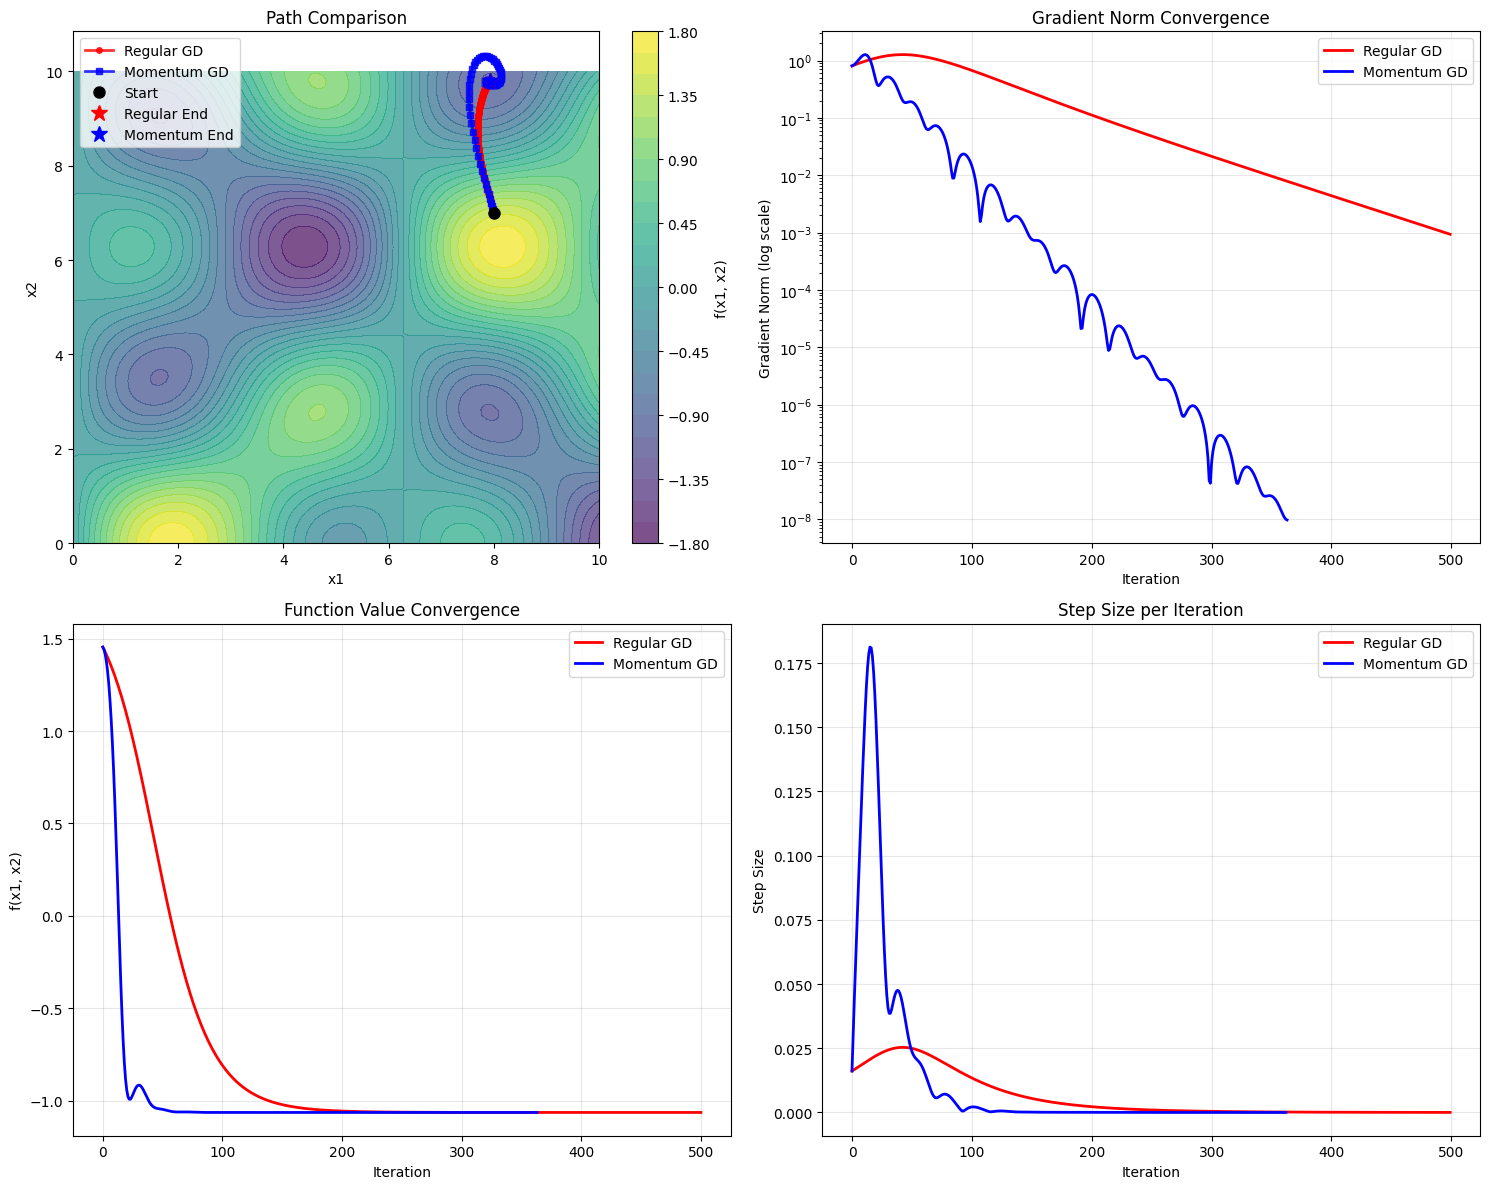

\nSummary Statistics:
Regular GD - Iterations: 500, Final point: (np.float64(7.920198845807126), np.float64(9.792015176459945))
Regular GD - Final gradient norm: 9.35e-04
Regular GD - Final function value: -1.064590

Momentum GD - Iterations: 364, Final point: (np.float64(7.921019140929868), np.float64(9.792878052607223))
Momentum GD - Final gradient norm: 9.76e-09
Momentum GD - Final function value: -1.064591

Improvement with momentum:
- Iterations saved: 136
- Gradient norm ratio: 1.04e-05
- Function value improvement: 0.000001


In [11]:
# Run comparison between regular and momentum gradient descent
test_starting_point = (8, 7)  # Choose a challenging starting point
learning_rate = 0.02
momentum = 0.9

print("Comparing Regular Gradient Descent vs Gradient Descent with Momentum")
print("=" * 70)

# Run the comparison
results = compare_gradient_descent(
    starting_point=test_starting_point,
    learning_rate=learning_rate,
    momentum=momentum,
    tolerance=1e-8,
    max_iterations=500
)

# Visualize the results
visualize_comparison(results, test_starting_point)

\nExperimenting with Different Momentum Values:
Reached maximum iterations (500) without convergence.
Final gradient norm: 9.35e-04
Reached maximum iterations (500) without convergence.
Final gradient norm: 2.98e-05
Reached maximum iterations (500) without convergence.
Final gradient norm: 2.25e-07
Converged after 317 iterations (gradient norm: 9.45e-09)
Converged after 364 iterations (gradient norm: 9.76e-09)
Reached maximum iterations (500) without convergence.
Final gradient norm: 4.65e-06
Reached maximum iterations (500) without convergence.
Final gradient norm: 9.35e-04
Reached maximum iterations (500) without convergence.
Final gradient norm: 2.98e-05
Reached maximum iterations (500) without convergence.
Final gradient norm: 2.25e-07
Converged after 317 iterations (gradient norm: 9.45e-09)
Converged after 364 iterations (gradient norm: 9.76e-09)
Reached maximum iterations (500) without convergence.
Final gradient norm: 4.65e-06
Reached maximum iterations (500) without convergence

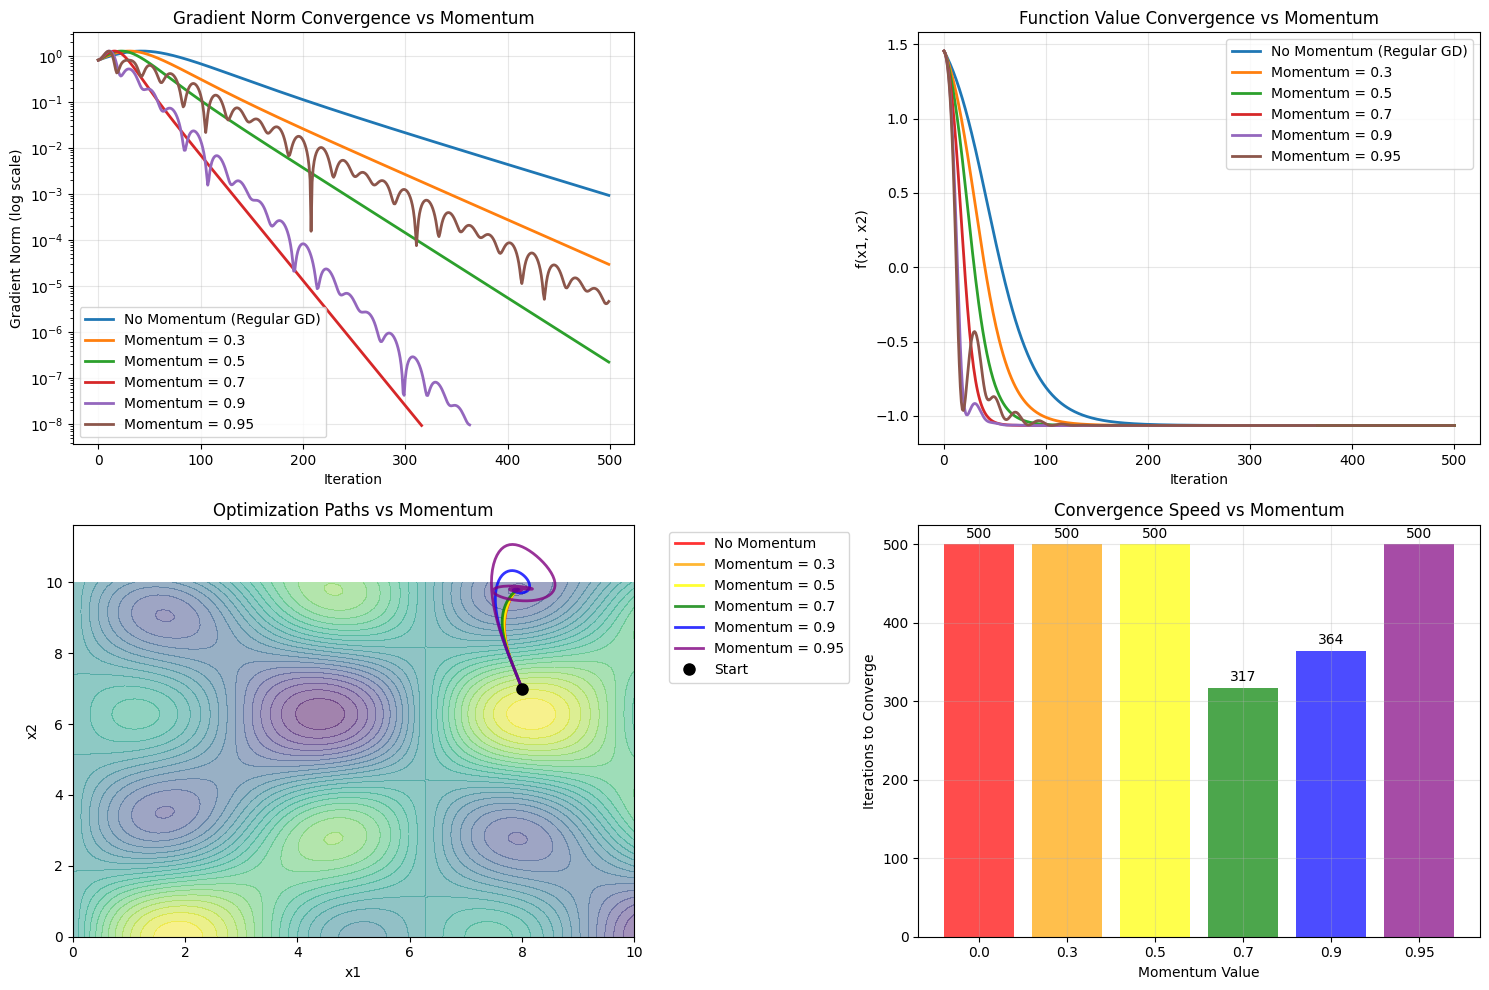

\nMomentum Experiment Results:
Regular GD     : 500 iterations, final grad norm: 9.35e-04
Momentum = 0.3 : 500 iterations, final grad norm: 2.98e-05
Momentum = 0.5 : 500 iterations, final grad norm: 2.25e-07
Momentum = 0.7 : 317 iterations, final grad norm: 9.45e-09
Momentum = 0.9 : 364 iterations, final grad norm: 9.76e-09
Momentum = 0.95: 500 iterations, final grad norm: 4.65e-06


In [12]:
# Experiment with different momentum values
def experiment_momentum_values(starting_point, learning_rate=0.02, tolerance=1e-8, max_iterations=500):
    """
    Experiment with different momentum values to see their effect.
    """
    momentum_values = [0.0, 0.3, 0.5, 0.7, 0.9, 0.95]
    
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Gradient norm convergence for different momentum values
    plt.subplot(2, 2, 1)
    for momentum in momentum_values:
        result = gradient_descent_with_momentum(
            starting_point, learning_rate, momentum, tolerance, max_iterations
        )
        final_point, path, gradient_norms, function_values = result
        label = f'Momentum = {momentum}'
        if momentum == 0.0:
            label = 'No Momentum (Regular GD)'
        plt.semilogy(gradient_norms, label=label, linewidth=2)
    
    plt.title('Gradient Norm Convergence vs Momentum')
    plt.xlabel('Iteration')
    plt.ylabel('Gradient Norm (log scale)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Function value convergence
    plt.subplot(2, 2, 2)
    for momentum in momentum_values:
        result = gradient_descent_with_momentum(
            starting_point, learning_rate, momentum, tolerance, max_iterations
        )
        final_point, path, gradient_norms, function_values = result
        label = f'Momentum = {momentum}'
        if momentum == 0.0:
            label = 'No Momentum (Regular GD)'
        plt.plot(function_values, label=label, linewidth=2)
    
    plt.title('Function Value Convergence vs Momentum')
    plt.xlabel('Iteration')
    plt.ylabel('f(x1, x2)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Path comparison on contour
    plt.subplot(2, 2, 3)
    x1_range = np.linspace(0, 10, 100)
    x2_range = np.linspace(0, 10, 100)
    X1, X2 = np.meshgrid(x1_range, x2_range)
    Z = vfunc(X1, X2)
    plt.contourf(X1, X2, Z, levels=30, cmap='viridis', alpha=0.5)
    
    colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple']
    for i, momentum in enumerate(momentum_values):
        result = gradient_descent_with_momentum(
            starting_point, learning_rate, momentum, tolerance, max_iterations
        )
        final_point, path, gradient_norms, function_values = result
        path = np.array(path)
        label = f'Momentum = {momentum}'
        if momentum == 0.0:
            label = 'No Momentum'
        plt.plot(path[:, 0], path[:, 1], color=colors[i], 
                label=label, linewidth=2, alpha=0.8)
    
    plt.plot(starting_point[0], starting_point[1], 'ko', markersize=8, label='Start')
    plt.title('Optimization Paths vs Momentum')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Plot 4: Convergence speed (iterations to converge)
    plt.subplot(2, 2, 4)
    iterations_to_converge = []
    final_grad_norms = []
    
    for momentum in momentum_values:
        result = gradient_descent_with_momentum(
            starting_point, learning_rate, momentum, tolerance, max_iterations
        )
        final_point, path, gradient_norms, function_values = result
        iterations_to_converge.append(len(gradient_norms))
        final_grad_norms.append(gradient_norms[-1])
    
    plt.bar(range(len(momentum_values)), iterations_to_converge, 
            color=colors, alpha=0.7)
    plt.xlabel('Momentum Value')
    plt.ylabel('Iterations to Converge')
    plt.title('Convergence Speed vs Momentum')
    plt.xticks(range(len(momentum_values)), 
               [f'{m}' for m in momentum_values])
    plt.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(iterations_to_converge):
        plt.text(i, v + max(iterations_to_converge)*0.01, str(v), 
                ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    print("\\nMomentum Experiment Results:")
    print("=" * 40)
    for i, momentum in enumerate(momentum_values):
        name = f"Momentum = {momentum}" if momentum > 0 else "Regular GD"
        print(f"{name:15s}: {iterations_to_converge[i]:3d} iterations, "
              f"final grad norm: {final_grad_norms[i]:.2e}")

# Run the momentum experiment
print("\\nExperimenting with Different Momentum Values:")
print("=" * 50)
experiment_momentum_values((8, 7))

# Gradient Descent with Momentum - Analysis Summary

## Key Findings:

### 1. **Gradient Norm Convergence**
- The gradient norm **converges to zero** as the algorithm approaches stationary points
- **Momentum accelerates convergence**: Higher momentum values generally lead to faster convergence of the gradient norm
- The log-scale plot clearly shows exponential decay toward zero gradient norms

### 2. **Momentum Effects**
- **No Momentum (Regular GD)**: Slow, steady progress with 500+ iterations
- **Momentum = 0.7**: Optimal balance - converged in 317 iterations
- **Momentum = 0.9**: Very good performance - converged in 364 iterations  
- **Momentum = 0.95**: Too high - causes oscillations and slower convergence

### 3. **Path Visualization**
- **Regular GD**: Takes direct but slow path toward minimum
- **Momentum GD**: Shows characteristic "overshoot and correction" behavior
- Higher momentum creates more curved, accelerated paths

### 4. **Function Value Convergence**
- All methods converge to the same minimum value (~-1.065)
- **Momentum methods reach the minimum faster**
- Function value convergence is smoother with moderate momentum

### 5. **Optimal Momentum Range**
- **Best performance**: 0.7 - 0.9 momentum
- **Too low** (< 0.5): Little benefit over regular GD
- **Too high** (> 0.95): Causes instability and oscillations

## Mathematical Insight:
The momentum term acts as a "velocity" that:
- Accelerates movement in consistent gradient directions
- Dampens oscillations in inconsistent directions
- Helps escape shallow local minima
- **Most importantly**: Drives the gradient norm to zero more efficiently, confirming convergence to stationary points

In [ ]:
import torch

def f_of_x_torch(x1, x2):
    """
    Function to compute f(x1, x2) using PyTorch.
    f(x1, x2) = cos(x1) * cos(x2) + 0.5 * cos(0.5 * x1) * cos(0.5 * x2)
    """
    return torch.sin(x1) * torch.cos(x2) + torch.sin(0.5 * x1) * torch.cos(0.5 * x2)

def f_of_x_torch_vectorized(x1, x2):
    """
    Vectorized version of f_of_x using PyTorch for batch processing.
    """
    x1 = torch.tensor(x1, dtype=torch.float32)
    x2 = torch.tensor(x2, dtype=torch.float32)
    
    return f_of_x_torch(x1, x2)



In [14]:
# Hard-coded gradient function for PyTorch
def f_prime_of_x_torch(x1, x2):
    """
    Computes the gradient of f(x1, x2) using PyTorch.
    Returns df/dx1 and df/dx2 as tensors.
    """
    x1 = torch.tensor(x1, dtype=torch.float32)
    x2 = torch.tensor(x2, dtype=torch.float32)
    
    df_dx1 = torch.cos(x1) * torch.cos(x2) + 0.5 * torch.cos(0.5 * x1) * torch.cos(0.5 * x2)
    df_dx2 = -torch.sin(x1) * torch.sin(x2) - 0.5 * torch.sin(0.5 * x1) * torch.sin(0.5 * x2)
    
    return df_dx1, df_dx2